In [1]:
%load_ext autoreload
%autoreload 2
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
# Load the NumPy array from a pickle file
with open('../Data/MP_data/displacements0-5000.pkl', 'rb') as file:
    dis_array = pickle.load(file)

In [3]:
dis_array.shape

(5000, 1317, 3)

In [4]:
from neuralop.layers.neighbor_search import NeighborSearch
from neuralop.layers.integral_transform import IntegralTransform

In [5]:
mesh = np.loadtxt('../Data/MP_data/mesh.csv', delimiter=',')

In [6]:
print(np.max(mesh[0,:]), np.max(mesh[1,:]))

2.5 0.41


In [7]:
idx_x = torch.arange(0,2.51+(2.51/100), 2.51/100)
idx_y = torch.arange(0,.42, 0.42/20)
x, y  = torch.meshgrid(idx_x, idx_y, indexing='ij') 


In [8]:
print(x.shape, y.shape, idx_x.shape, idx_y.shape, torch.max(x), torch.max(y))

torch.Size([102, 20]) torch.Size([102, 20]) torch.Size([102]) torch.Size([20]) tensor(2.5351) tensor(0.3990)


In [9]:
simple_mesh = torch.stack([x.flatten(), y.flatten()]).type(torch.float)

In [10]:
com_mesh = torch.stack( [torch.tensor(mesh[0,:]),torch.tensor(mesh[1,:])]).type(torch.float)

In [11]:
print(com_mesh.shape, simple_mesh.shape)

torch.Size([2, 1317]) torch.Size([2, 2040])


In [12]:
NS = NeighborSearch(use_open3d=False)
pos_dict_tosimple = NS(torch.transpose(com_mesh, 0, 1), torch.transpose(simple_mesh,0, 1), radius=0.1)

In [13]:
temp = pos_dict_tosimple['neighbors_row_splits']
temp2 = temp[1:]-temp[:-1]
print(min(temp2),max(temp2))
print(len(temp2))

tensor(2) tensor(416)
2040


In [14]:
print(pos_dict_tosimple.keys())

dict_keys(['neighbors_index', 'neighbors_row_splits'])


In [15]:
NS_2 = NeighborSearch(use_open3d=False)
pos_dict_tocomplex = NS_2( torch.transpose(simple_mesh,0, 1),torch.transpose(com_mesh, 0, 1), radius=0.8)

In [16]:
temp = pos_dict_tocomplex['neighbors_row_splits']
temp2 = temp[1:]-temp[:-1]
print(min(temp2),max(temp2))
print(len(temp2))

tensor(616) tensor(1264)
1317


In [17]:
it = IntegralTransform(mlp_layers=[4,1]).cuda()

In [18]:
f = com_mesh[0,:]**2+com_mesh[1,:]**2
print(f.shape)

torch.Size([1317])


In [19]:
for key, value in pos_dict_tosimple.items():
    pos_dict_tosimple[key] = pos_dict_tosimple[key].cuda()
with torch.no_grad():
    f_x = it(torch.transpose(com_mesh, 0, 1).cuda(),pos_dict_tosimple, torch.transpose(simple_mesh,0, 1).cuda(),f.reshape(-1,1).cuda() )

In [20]:
f_x.shape

torch.Size([2040, 1])

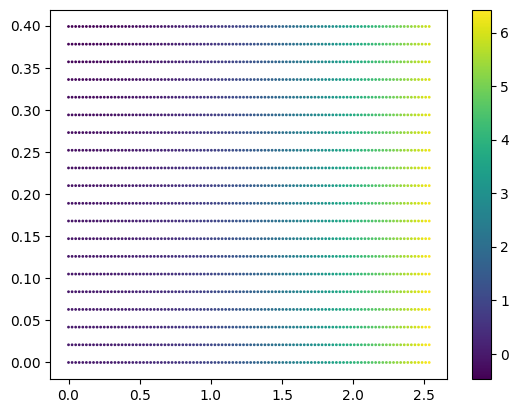

In [21]:
plt.scatter(simple_mesh[0,:].cpu(), simple_mesh[1:].cpu(),c=simple_mesh[0,:].cpu()**2 - 3*simple_mesh[1:].cpu()**2 , cmap='viridis', s=1.0)
plt.colorbar()

In [ ]:
torch.transpose(simple_mesh,0, 1).shape

In [ ]:
from data_utils.data_utils import MakserNonuniformMest

In [ ]:
masker = MakserNonuniformMest(torch.transpose(com_mesh, 0, 1).cuda(),torch.transpose(simple_mesh,0, 1).cuda(), 0.04)

In [26]:
_, mask = masker((1317, 7),max_block=0.7, drop_pix=0.3,\
                 channel_aug_rate = 0.8, channel_drop_rate = 0.4, device='cuda', min_block=10, max_blocks=100 )

In [27]:
mask[:,1]

tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')

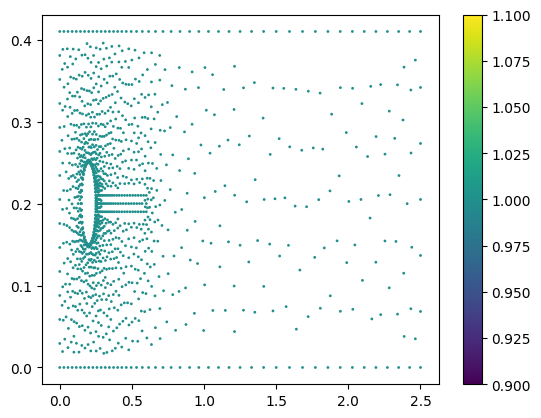

In [28]:
plt.scatter(mesh[0,:], mesh[1:],c=mask[:,4].cpu(), cmap='viridis', s=1.0)
plt.colorbar()

In [29]:
f

tensor([0.0000, 0.1681, 6.4181,  ..., 0.1098, 0.1204, 0.1166])

In [30]:
f[masker.in_nbr[-1].long()==1] = 0

In [31]:
print(f)

tensor([0.0000, 0.1681, 0.0000,  ..., 0.1098, 0.1204, 0.1166])


In [32]:
simple_mesh.shape

torch.Size([2, 10542])

In [71]:
from models.gino import Gino

In [72]:
model = Gino(1, torch.transpose(com_mesh, 0, 1).cuda(),\
             output_grid=torch.transpose(simple_mesh, 0, 1).cuda(),
             grid_size=(251,42),
             radius=0.08,
             n_modes=[[20,40]]*4,
             scalings=[[1,1]]*4,
             n_heads=[2]*4,
             hidden_token_codim=5,
             gno_mlp_layers=[4,8],
             var_encoding=False,
             var_num=5,
             lifting=False,
             var_enco_channels=2,
             enable_cls_token=False,
              )

End to End Scaling [1, 1]
expected number of channels 25
1.0 None 2 2 [10, 20]
Token dim 5 number heads 2 Head co-dim 2
std 0.1414213562373095
Using Half modes 5 10
std 0.1414213562373095
Using Half modes 5 10
std 0.1414213562373095
Using Half modes 10 20
std 0.15811388300841897
Using Half modes 10 20
Permutation Equivariant with  5
std 0.1414213562373095
Using Half modes 10 20
1.0 None 2 2 [10, 20]
Token dim 5 number heads 2 Head co-dim 2
std 0.1414213562373095
Using Half modes 5 10
std 0.1414213562373095
Using Half modes 5 10
std 0.1414213562373095
Using Half modes 10 20
std 0.15811388300841897
Using Half modes 10 20
Permutation Equivariant with  5
std 0.1414213562373095
Using Half modes 10 20
1.0 None 2 2 [10, 20]
Token dim 5 number heads 2 Head co-dim 2
std 0.1414213562373095
Using Half modes 5 10
std 0.1414213562373095
Using Half modes 5 10
std 0.1414213562373095
Using Half modes 10 20
std 0.15811388300841897
Using Half modes 10 20
Permutation Equivariant with  5
std 0.14142135623

In [46]:
model = model.cuda()
y = model(torch.randn(1, 30, 251, 42).cuda())

projection
Input Shape torch.Size([1, 10542, 30])
Input Shape after Var Encdoing torch.Size([1, 10542, 30])
Input Shape after Rearrange torch.Size([10542, 6, 5])
0
torch.Size([10542, 1])
1
torch.Size([10542, 1])
2
torch.Size([10542, 1])
3
torch.Size([10542, 1])
4
torch.Size([10542, 1])
5
torch.Size([10542, 1])
Output Shape after Rearrange torch.Size([1, 1317, 6])


In [47]:
print(y.shape)
#plt.imshow(y[0,1].detach().cpu())

torch.Size([1, 1317, 6])


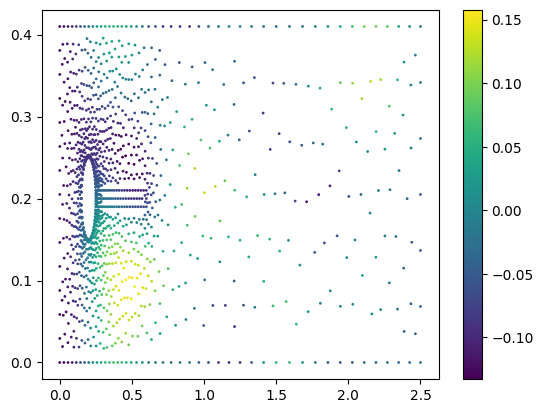

In [37]:
plt.scatter(mesh[0,:], mesh[1:],c=y[0,:,4].detach().cpu(), cmap='viridis', s=1.0)
plt.colorbar()

In [91]:
from YParams import YParams
from models.get_models import get_ssl_models_Gino, SslWrapper

In [92]:
params = YParams('./config/ssl.yaml', 'gino', print_params=True)

------------------ Configuration ------------------
batch_size 1
input_mesh_location ../Data/MP_data/mesh.csv
radius 0.08
gno_mlp_layers [6, 8]
grid_size [251, 42]
grid_type non uniform
n_modes_en [[100, 20], [100, 20]]
n_modes_dec [[100, 20], [100, 20]]
n_modes_pred [[100, 20], [100, 20], [100, 20]]
masking_radius 0.08
evaluation_channel_drop 1
drop_type zeros
max_block 0.6
drop_pix 0.7
channel_per 0.3
channel_drop_per 0.1
validation_aug False
max_block_val 0.2
drop_pix_val 0.15
channel_per_val 0.5
channel_drop_per_val 0.5
var_num 7
in_token_codim_en 1
hidden_token_codim_en 6
lifting_token_codim_en 12
lifting_token_codim_pred 12
out_token_codim_pred 1
n_layers_en 2
n_heads_en [2, 2]
n_layers_dec 2
n_heads_dec [2, 2]
n_layers_pred 3
n_heads_pred [2, 2, 2]
scalings_pred [[1, 1], [1, 1], [1, 1]]
scalings_en [[1, 1], [1, 1]]
scalings_dec [[1, 1], [1, 1]]
per_channel_attention True
fft_type fft
tno_integral_op fno
var_encoding True
var_enco_channels 3
reconstruction True
enable_cls_token T

In [93]:
encoder, decoder, contrastive, predictor = get_ssl_models_Gino(params)
model = SslWrapper(params, encoder, decoder, contrastive, predictor, stage='ssl')

Generating Encoder
Token Dim--> 4
var num 7 static channels 0
End to End Scaling [1, 1]
Using lifing Layer
expected number of channels 48
1.0 None 1 4 [25, 5]
std 0.31622776601683794
Using Half modes 12 2
std 0.31622776601683794
Using Half modes 12 2
std 0.31622776601683794
Using Half modes 50 10
std 0.22360679774997896
Using Half modes 50 10
Permutation Equivariant with  6
std 0.12909944487358055
Using Half modes 50 10
1.0 None 1 4 [25, 5]
std 0.31622776601683794
Using Half modes 12 2
std 0.31622776601683794
Using Half modes 12 2
std 0.31622776601683794
Using Half modes 50 10
std 0.22360679774997896
Using Half modes 50 10
Permutation Equivariant with  6
std 0.12909944487358055
Using Half modes 50 10
intializing CLS token
*********************
Generating Decoder
End to End Scaling [1, 1]
expected number of channels 42
1.0 None 1 4 [25, 5]
std 0.31622776601683794
Using Half modes 12 2
std 0.31622776601683794
Using Half modes 12 2
std 0.31622776601683794
Using Half modes 50 10
std 0.2236

In [94]:
y,_,_,_ = model.cuda()(torch.randn(1,1317,7).cuda())
print(y.shape)

TypeError: randint() got an unexpected keyword argument 'low'

In [ ]:
plt.scatter(mesh[0,:], mesh[1:],c=y[0,:,9].detach().cpu(), cmap='viridis', s=1.0)
plt.colorbar()

In [ ]:
e = encoder.cuda()(torch.randn(1,1317,10).cuda())
print("Encoding ", e.shape)
out = decoder.cuda()(e)
print("Reconstructed", out.shape)
p = predictor.cuda()(e)
print('next time', p.shape)

In [110]:
from data_utils.data_loaders import get_onestep_dataloader

In [111]:
train, test = get_onestep_dataloader()

tensor([-2.2428e-04,  1.4606e-04,  0.0000e+00,  1.5814e+00,  1.4520e-03,
         0.0000e+00, -3.0803e+02])
tensor([8.6552e-04, 5.6311e-03, 0.0000e+00, 1.4199e+00, 5.0962e-01, 0.0000e+00,
        1.8482e+03])


In [109]:
for i in train:
    print(i[0].shape, i[1].shape)
    #i[0] = torch.nn.functional.normalize(i[0], p=2.0, dim=1)
    for j in range(7):
        print(torch.max(i[0][0,:,j]))
    break

torch.Size([1, 1317, 7]) torch.Size([1, 1317, 7])
tensor(1.4257)
tensor(0.9944)
tensor(0.)
tensor(1.8122)
tensor(4.3653)
tensor(0.)
tensor(3.9964)


In [98]:
from train.trainer import simple_trainer

In [ ]:
simple_trainer(model.cuda(), train, test, params)

In [88]:
model.agumenter_masker.in_nbr.shape

torch.Size([10542, 1317])

In [114]:
_, mask = model.agumenter_masker((1317,7))

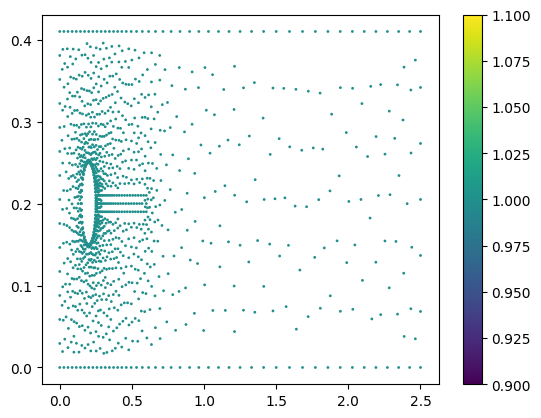

In [122]:
plt.scatter(mesh[0,:], mesh[1:],c=mask[:,6].cpu(), cmap='viridis', s=1.0)
plt.colorbar()

In [101]:
r = torch.randn(5000, 100, 7)
mean = torch.mean(r, dim=(0,1))
var = torch.var(r, dim=(0,1))

In [102]:
mean

tensor([-3.4005e-06,  5.1811e-04,  2.5923e-04,  2.4100e-03, -1.4543e-03,
        -2.1086e-03, -2.3211e-03])

In [103]:
var

tensor([0.9995, 1.0012, 0.9980, 0.9991, 1.0000, 0.9980, 1.0036])

In [104]:
r = (r - mean)/var

In [23]:
from neuralop.models.fnogno import FNOGNO

fnogno = FNOGNO(3,\
            3,
            projection_channels= 64,
            gno_coord_dim=2,
            gno_coord_embed_dim=None,
            gno_radius=0.033,
            gno_mlp_hidden_layers=[12, 12],
)

std 0.0006176323555016366


In [26]:
k = fnogno(torch.transpose(com_mesh, 0, 1),torch.transpose(com_mesh, 0, 1), torch.randn(1317,3))

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 2 is not equal to len(dims) = 4

In [25]:
com_mesh.shape

torch.Size([2, 1317])